## <b>Lecture08 언어 모델 RNNs</b>

###목표
 - RNNs(**Recurrent Neural Networks**) 구조를 직접 구현 및 학습시켜 본다.

## 참조
 - Stanford CS224n: [`https://web.stanford.edu/class/cs224n/`](https://web.stanford.edu/class/cs224n/)
 - CMU ANLP: [`https://cmu-l3.github.io/anlp-spring2025/`](https://cmu-l3.github.io/anlp-spring2025/)

## 설명

### RNN이란
•	**RNN (Recurrent Neural Network)** 은 순서열 데이터를 처리하기 위해 고안된 모델 구조이다.  
•	매 스텝마다 입력을 처리한다. 동시에 이전 스텝의 정보를 담고 있는 은닉 상태(hidden state)를 관리한다.
`I → love → deep → learning → <EOS>`  

### RNN으로 언어를 학습하는 이유
•	Bag-of-Words와 달리, RNN는 단어의 순서를 저장한다.
•	문장에서 다음 단어를 예측하기 유리하다.  
•	원하는 길이의 문장을 생성하기 유리하다.  

### 특화된 작업  
•	문장 생성
•	번역
•	음성인식
•	시계열 데이터 예측

## 데이터 준비

In [ ]:
import requests

url = 'https://drive.google.com/uc?export=download&id=1R_0mUiIjOhwhqOubuJb4UA1658ioVpHa'
response = requests.get(url)
data = response.text.splitlines()
data[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
# 각 알파벳 마다(abcdefghijklmnopqrstuvwxyz) 숫자값을 부여한다
token_to_index = {tok: i for i, tok in enumerate('abcdefghijklmnopqrstuvwxyz')} #todo

# 토큰(token)은 인공지능이 이해하는 단어이다.
# 문장의 시작/끝을 의미하는 토큰을 추가한다.(Start/Stop)
token_to_index['[S]'] = 26

# 모든 문장의 길이를 동일하게 만드는 의미없는 토큰 (padding)
token_to_index['[PAD]'] = 27

print(token_to_index)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, '[S]': 26, '[PAD]': 27}


In [ ]:
# 숫자값을 토큰으로 되돌리기

index_to_token = {i: tok for tok, i in token_to_index.items()} #todo

print(index_to_token)

{0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 9: 'j', 10: 'k', 11: 'l', 12: 'm', 13: 'n', 14: 'o', 15: 'p', 16: 'q', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'x', 24: 'y', 25: 'z', 26: '[S]', 27: '[PAD]'}


In [ ]:
# 해당 token_to_index 혹은 index_to_token의 길이는 인공지능이 알고 있는 전체 단어의 수와 같다.
# 전체 단어 수 = vocab size

vocab_size = len(token_to_index)
print(vocab_size)

28


In [ ]:
import torch

def build_dataset(data):
    X, y = [], []

    for item in data:
      tokens = ['[S]'] + list(item) + ['[S]'] #stop token<-->데이터<--> stop token
      indices = [token_to_index[token] for token in tokens]
      X.append(indices[:-1])
      y.append(indices[1:])

    return X, y

In [ ]:
# 학습, 검증, 검사 데이터로 나눈다.
import random
random.seed(123)
random.shuffle(data)

n1 = int(0.8 * len(data))
n2 = int(0.9 * len(data))

print("====== TRAIN ======")
X_train, y_train = build_dataset(data[:n1])
print("====== DEV ======")
X_dev, y_dev = build_dataset(data[n1:n2])
print("====== TEST ======")
X_test, y_test = build_dataset(data[n2:])

len(X_train), len(y_train)

====== TRAIN ======
====== DEV ======
====== TEST ======


(25626, 25626)

## RNN 모델

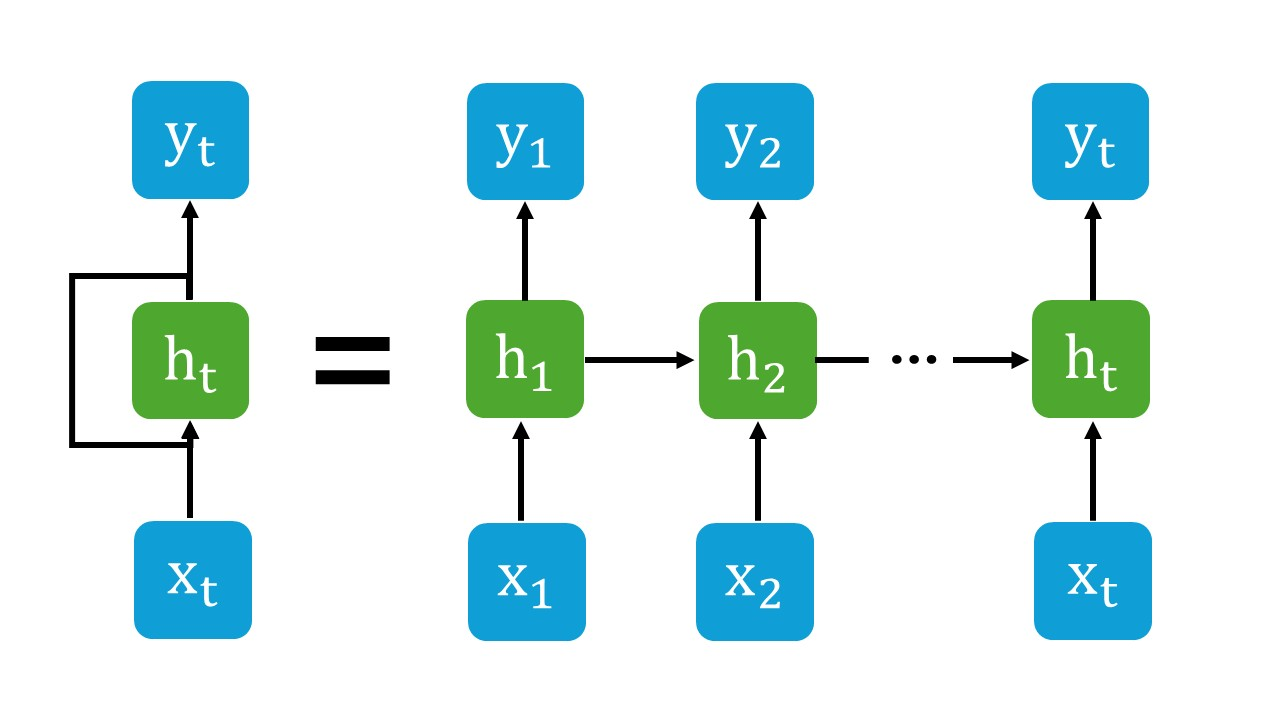

<center><i>RNN architecture</i></center>

In [ ]:
import torch
import torch.nn as nn

# RNN Cell 하나를 정의함 (즉, 한 시점의 연산 단위)
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(RNNCell, self).__init__()

        # 입력 벡터 크기와 은닉 상태(hidden state)의 크기를 저장
        self.input_size = input_size
        self.hidden_size = hidden_size

        # hidden state와 input 각각에 대해 Linear 변환을 적용 (bias는 따로 정의)
        self.Wh = nn.Linear(in_features=hidden_size,
                            out_features=hidden_size,
                            bias=False)

        self.Wx = nn.Linear(in_features=input_size,
                            out_features=hidden_size,
                            bias=False)

        # bias를 직접 하나의 파라미터로 정의 (초기값은 0로 설정하겠다.)
        # 기본 requires_grad=True (학습 가능 파라미터)
        self.b = nn.Parameter(torch.zeros(hidden_size),
                              requires_grad=True)

        # 활성화 함수로 tanh 사용
        self.activation = nn.Tanh()

    def forward(self, x, h_prev):
        h = self.activation(self.Wx(x) + self.Wh(h_prev) +self.b)

        return h


# RNN Language Model 구조 전체
# 단어를 입력으로 받아 임베딩 → RNN 연산 → vocab 크기로 출력
class RNNLM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(RNNLM, self).__init__()

        # 단어 인덱스를 벡터로 바꿔주는 임베딩 층
        self.embedding = nn.Embedding(num_embeddings=vocab_size,
                                      embedding_dim=hidden_size)

        # 위에서 만든 RNNCell 사용
        self.rnn = RNNCell(input_size=hidden_size,
                           hidden_size=hidden_size)

        # RNN의 출력을 vocab 크기의 확률 분포로 변환
        self.output = nn.Linear(in_features=hidden_size,
                                out_features=vocab_size,
                                bias=True)

        # 기본 파라미터 저장
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size

    def forward(self, x, hidden=None):
        # hidden state 초기화 (없으면 0으로)
        if hidden is None:
            hidden = self.init_hidden(x.size(0))

        # x.shape: [batch_size, seq_len]
        x = self.embedding(x)

        # 전체 시점에서의 hidden states를 담기 위한 outs
        outs = []

        # 각 시점별 RNNCell 연산 구현
        seq_len = x.size(1)
        for i in range(seq_len):
            # i번째 시점의 단어 벡터 추출 (x의 i번째 단어)
            # x: [batch_size, seq_len, hidden_size]
            # x[:, i:i+1] -> i번째의 [batch_size, 1, hidden_size]
            x_t = x[:, i:i+1]
            # x_t = x[:, i, :].unsqueeze(1)

            # RNNCell에 입력
            # 이전 hidden과 현재 입력을 RNN에 넣고 다음 hidden 계산
            hidden = self.rnn(x_t, hidden)

            # output layer 통과
            out = self.output(hidden)
            outs.append(out)

        # 모든 시점의 출력을 시간 차원으로 이어붙임
        # [out_t0, out_t1, out_t2...]
        outs = torch.cat(outs, dim=1)

        return outs, hidden

    # RNN의 첫 hidden size를 초기화하는 함수
    def init_hidden(self, batch_size):
        # 모든 hidden state를 0으로 초기화
        return torch.zeros(batch_size, 1, self.hidden_size)

In [ ]:
# dataset에서 정의한 vocab_size와, hidden_size는 32로 설정
model = RNNLM(vocab_size, 32)

# 하나만 샘플로 뽑아보기
x = torch.tensor(X_train[0]).unsqueeze(0)

# 테스트 수행
output, hidden = model(x, hidden=None)
output.size(), hidden.size()

(torch.Size([1, 6, 28]), torch.Size([1, 1, 32]))

In [ ]:
# batch 학습을 위한 padding 수행
def pad_batch(X_batch, y_batch, pad_index):

    # batch에서 padding을 할 때, 어디까지 [PAD]를 넣어줘야 할 지 판단하기 위해
    # batch 중 가장 긴 데이터의 길이를 구하기
    max_len = max(len(x) for x in X_batch)

    # 빈 부분들에 [PAD] 토큰 삽입
    X_padded = torch.zeros(len(X_batch), max_len, dtype=torch.long) + pad_index
    y_padded = torch.zeros(len(y_batch), max_len, dtype=torch.long) + pad_index

    # 데이터를 tensor로 변환하기
    # [padded_x_1, padded_x_2, padded_x_3, ...]
    # [padded_y_1, padded_y_2, padded_y_3, ...]
    for i, (x, y) in enumerate(zip(X_batch, y_batch)):
        X_padded[i, :len(x)] = torch.tensor(x)
        y_padded[i, :len(y)] = torch.tensor(y)

    return X_padded, y_padded

# 여기선 4개의 데이터를 하나의 batch로 만들기
xp, yp = pad_batch(X_train[:4], y_train[:4], token_to_index['[PAD]'])

print(xp)
for x in xp:
    print([index_to_token[i.item()] for i in x])

tensor([[26, 11, 20,  0, 13, 13, 27, 27, 27, 27],
        [26, 18,  7,  0,  8, 13, 27, 27, 27, 27],
        [26, 17, 20, 15,  4, 17, 19, 27, 27, 27],
        [26, 12, 14, 10, 18,  7,  0,  6, 13,  0]])
['[S]', 'l', 'u', 'a', 'n', 'n', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[S]', 's', 'h', 'a', 'i', 'n', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[S]', 'r', 'u', 'p', 'e', 'r', 't', '[PAD]', '[PAD]', '[PAD]']
['[S]', 'm', 'o', 'k', 's', 'h', 'a', 'g', 'n', 'a']


## 모델 학습

In [ ]:
import torch.optim as optim

# RNN 모델 만들기
model = RNNLM(vocab_size=len(token_to_index), hidden_size=96)

# 모델 파라미터
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# Hyperparameters
learning_rate = 0.001
num_epochs = 20
batch_size = 32

# Loss function and optimizer
# 알맞은 loss 고르기 (nn.CrossEntropyLoss(), nn.MSELoss(), ...)
# RNN에서는 크로스 엔트로피를 사용한다.
criterion = nn.CrossEntropyLoss(ignore_index=token_to_index['[PAD]'])

# optimizer 고르기 (optim.SGD(), optim.Adam(), optim.AdamW(), optim.RMSprop(), ...)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)


# Training loop
for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for i in range(0, len(X_train), batch_size):

        # 위에서 정의한 batch_size대로 batch 만들기
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        # 위에서 정의한 함수로 padding 수행
        X_batch, y_batch = pad_batch(X_batch, y_batch, token_to_index['[PAD]'])

        # Forward pass 수행하기
        # X_batch: [batch_size, seq_len, vocab_size]
        # 모델이 예측한 값
        outputs, _ = model(X_batch)
        outputs = outputs.view(-1, vocab_size)

        # 실제 정답
        y_batch = y_batch.view(-1)

        # loss 계산하기
        loss = criterion(outputs, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / (len(X_train) // batch_size)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    # validation loss
    eval_loss = 0
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_dev), batch_size):
            X_batch = X_dev[i:i+batch_size]
            y_batch = y_dev[i:i+batch_size]
            X_batch, y_batch = pad_batch(X_batch, y_batch, token_to_index['[PAD]'])

            # Forward pass 수행하기
            # X_batch: [batch_size, seq_len, vocab_size]
            outputs, _ = model(X_batch)
            outputs = outputs.view(-1, vocab_size)

            # 실제 정답
            # [batch_size, seq_len]
            y_batch = y_batch.view(-1)

            # loss 계산하기
            loss = criterion(outputs,y_batch)

            eval_loss += loss.item()

    num_batches = max(1, len(X_dev) // batch_size)
    avg_eval_loss = eval_loss / num_batches
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_eval_loss:.4f}')

Model parameters: 23932
Epoch [1/20], Loss: 3.2656
Epoch [1/20], Validation Loss: 3.1724
Epoch [2/20], Loss: 3.0272
Epoch [2/20], Validation Loss: 2.9464
Epoch [3/20], Loss: 2.8287
Epoch [3/20], Validation Loss: 2.7842
Epoch [4/20], Loss: 2.7028
Epoch [4/20], Validation Loss: 2.6902
Epoch [5/20], Loss: 2.6274
Epoch [5/20], Validation Loss: 2.6302
Epoch [6/20], Loss: 2.5753
Epoch [6/20], Validation Loss: 2.5855
Epoch [7/20], Loss: 2.5343
Epoch [7/20], Validation Loss: 2.5489
Epoch [8/20], Loss: 2.5003
Epoch [8/20], Validation Loss: 2.5182
Epoch [9/20], Loss: 2.4720
Epoch [9/20], Validation Loss: 2.4930
Epoch [10/20], Loss: 2.4490
Epoch [10/20], Validation Loss: 2.4727
Epoch [11/20], Loss: 2.4305
Epoch [11/20], Validation Loss: 2.4563
Epoch [12/20], Loss: 2.4155
Epoch [12/20], Validation Loss: 2.4428
Epoch [13/20], Loss: 2.4031
Epoch [13/20], Validation Loss: 2.4314
Epoch [14/20], Loss: 2.3925
Epoch [14/20], Validation Loss: 2.4216
Epoch [15/20], Loss: 2.3833
Epoch [15/20], Validation Lo

In [ ]:
# 모델로부터 문장을 생성하는 함수
def sample(model, context, max_length=100):
    # 평가 모드로 설정
    model.eval()

    # 생성된 토큰들 저장할 리스트
    output = []

    # 학습 중이 아니므로 gradient 계산 비활성화
    with torch.no_grad():
        # 입력 토큰 텐서 생성
        # [S] = 문장 시작 토큰 (Start token)
        # context = 이미 주어진 단어들의 인덱스 리스트
        # 최종 형태: [[시작토큰, 단어1, 단어2, ...]]
        x = torch.tensor([[token_to_index['[S]']] + context])

        # RNN의 초기 hidden state; model 안에서 초기화 될 예정
        hidden = None

        # 최대 max_length 길이만큼 반복하며 단어 생성
        for _ in range(max_length):
            # 모델에 현재 입력 x와 hidden state를 넣어 다음 예측 y, 다음 hidden을 얻음
            y, hidden = model(x, hidden)

            # y의 형태: [batch_size, seq_len, vocab_size]
            # 첫번째 batch에서 가져오겠다 ([0])
            # 문장의 마지막 시점의 예측 결과만 선택 ([-1])
            y = y[0, -1].softmax(dim=0)  # softmax로 확률 분포로 변환

            # 확률 분포에 따라 다음 단어를 "샘플링"
            # (확률이 높은 단어가 선택될 가능성이 큼)
            y = torch.multinomial(y, 1)  # 1개 단어만 뽑기

            # 선택된 인덱스를 실제 단어(token)으로 변환
            token = index_to_token[y.item()]

            # 만약 [S]가 다시 나오면 문장 끝으로 판단하고 종료
            if token == '[S]':
                break

            # 생성된 단어를 결과 리스트에 추가
            output.append(token)

            # 방금 뽑은 단어를 다음 입력으로 사용하기 위해 텐서 형태로 변환
            x = y.view(1, 1)

    # 생성된 토큰들을 문자열로 이어서 반환
    return ''.join(output)

In [ ]:
# batch가 1인 것을 의미
prompt = 'j' # j로 시작하는 단어를 출력해라

for i in range(10):
    out = sample(model, [token_to_index[tok] for tok in prompt])
    print(prompt + out)

kores
koreleuk
korei
koren
koren
koregenep
koreyni
korea
korenelon
koreia
